Ejercicio 1: Preparación, Limpieza y Columna Calculada

Contexto:

Antes de graficar en Seaborn, necesitamos cargar nuestro dataset con la configuración regional adecuada (sep=";", encoding="utf-8"), limpiar los nombres de columnas (eliminando caracteres invisibles como el BOM), imputar los valores nulos del precio con la mediana o promedio, y crear la columna venta_total.

Instrucción:

Importa pandas as pd, seaborn as sns y matplotlib.pyplot as plt.

Lee el archivo ventas_bogota_limpiar.csv, limpia los nombres de columnas, imputa los nulos de precio usando .median(), crea la columna venta_total (precio * cantidad) e imprime las primeras 3 filas.

In [ ]:
#1.importar la librerias si no las he importado antes

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#2.cargarel archivo
df = pd.read_csv("ventas_bogota_limpiar.csv", sep=";", encoding="utf-8")

In [ ]:
#3.limpiar los nombres de las columnas (eliminar BOM y espacios en blanco)
df.columns = df.columns.str.strip().str.replace("\ufeff", "", regex=False)
#4.imputar los valores nulos en la columna "precio" con la mediana
df["precio"] = df["precio"].fillna(df["precio"].median())
#5.crear una nueva columna "venta_total" que sea el resultado de multiplicar la columna "precio" por la columna "cantidad"
df["venta_total"] = df["precio"] * df["cantidad"]
#6. mostrar las primeras 3 filas del DataFrame  
print(df.head(3))

   id_venta       fecha   producto   categoria      precio  cantidad  \
0         1  2024-02-13    Monitor  Accesorios  1140503.31         6   
1         2  2024-02-29  Audífonos  Accesorios  2786223.89         2   
2         3  2024-04-05    Teclado  Accesorios   958850.40         3   

         ciudad metodo_pago cliente_satisfecho  venta_total  
0  Barranquilla     Tarjeta                 si   6843019.86  
1  Barranquilla         NaN                 si   5572447.78  
2          Cali         NaN                 No   2876551.20  


Ejercicio 2: Gráfico de Dispersión Multivariado

(sns.scatterplot)

Contexto:

Queremos analizar visualmente si existe una relación entre la cantidad de unidades vendidas y el valor total de la venta, diferenciando los puntos por la categoría del producto.

Instrucción:

Utiliza sns.scatterplot() asignando x="cantidad" y y="venta_total", y usa hue="categoria" para colorear las series. Añade un título descriptivo y muestra la gráfica con plt.show().


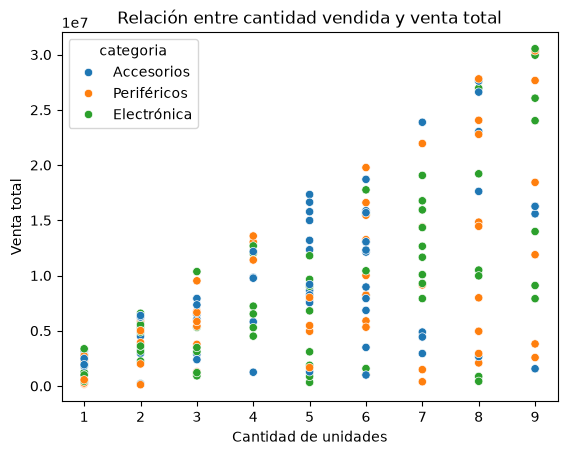

In [ ]:
#2.crear el grafico de dispersión
sns.scatterplot(
    data=df,
    x="cantidad",
    y="venta_total",
    hue="categoria"
)
#3.titulo y etiquetas de los ejes
plt.title("Relación entre cantidad vendida y venta total")
plt.xlabel("Cantidad de unidades")
plt.ylabel("Venta total")
#4.mostrar el grafico
plt.show()


Ejercicio 3: Diagrama de Caja por Ciudad

(sns.boxplot)

Contexto:

El equipo comercial necesita evaluar la distribución de la venta_total en cada ciudad para identificar en qué región se concentran los valores más altos o si existen valores atípicos (outliers).

Instrucción:

Filtra previamente el DataFrame para eliminar o rellenar los valores nulos de la columna ciudad con "No asignada". Luego, utiliza sns.boxplot() colocando x="ciudad" y y="venta_total". Añade título y etiquetas.

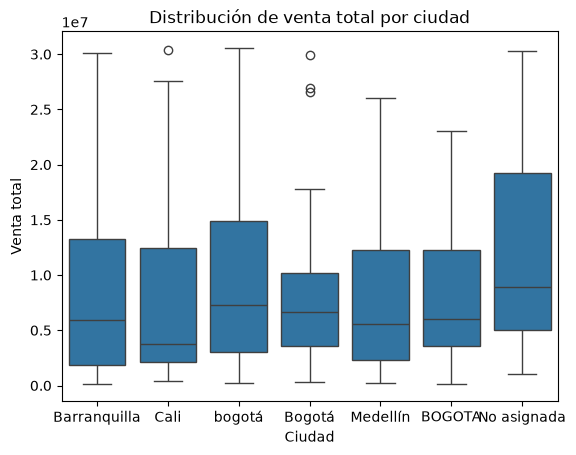

In [9]:
#1.reemplezar los nulos en la columna ciudad

df["ciudad"] = df["ciudad"].fillna("No asignada")

#2.crear el diagrama de caja
sns.boxplot(
    data=df,
    x="ciudad",
    y="venta_total"
)
#3.titulo y etiquetas de los ejes
plt.title("Distribución de venta total por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Venta total")

#4.mostrar el diagrama
plt.show()

Ejercicio 4: Conteo de Frecuencias por Método de Pago

(sns.countplot)

Contexto:

Queremos conocer de forma visual cuál es la preferencia de los clientes respecto al método de pago utilizado en las transacciones registradas.

Instrucción:

Rellena los valores nulos de la columna metodo_pago con "No registrado". Utiliza sns.countplot() para graficar la frecuencia de cada método de pago ordenado de mayor a menor (order=...

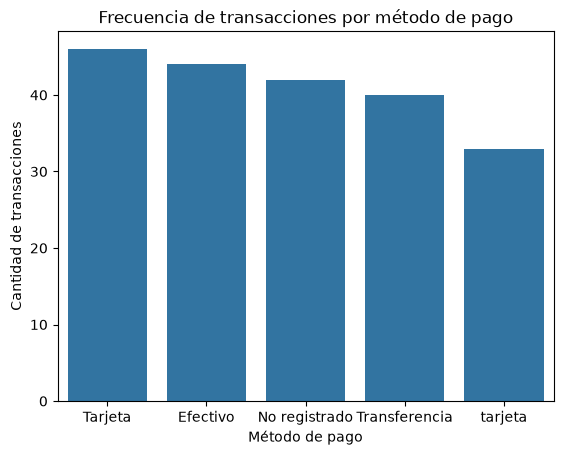

In [10]:
# Reemplazar valores nulos
df["metodo_pago"] = df["metodo_pago"].fillna("No registrado")

# Obtener el orden de mayor a menor
orden = df["metodo_pago"].value_counts().index

# Crear el gráfico
sns.countplot(
    data=df,
    x="metodo_pago",
    order=orden
)

# Título y etiquetas
plt.title("Frecuencia de transacciones por método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Cantidad de transacciones")

# Mostrar la gráfica
plt.show()


Ejercicio 5: Histograma y Curva de Densidad (sns.histplot)

* Contexto:

Para entender la forma estadística de nuestra variable de ingresos (venta_total), graficaremos un histograma superpuesto con una curva de densidad de probabilidad (KDE).

* Instrucción:

Utiliza sns.histplot() con x="venta_total", activando los parámetros kde=True y bins=15. Añade líneas verticales o un título claro que refleje la distribución de los montos de venta.

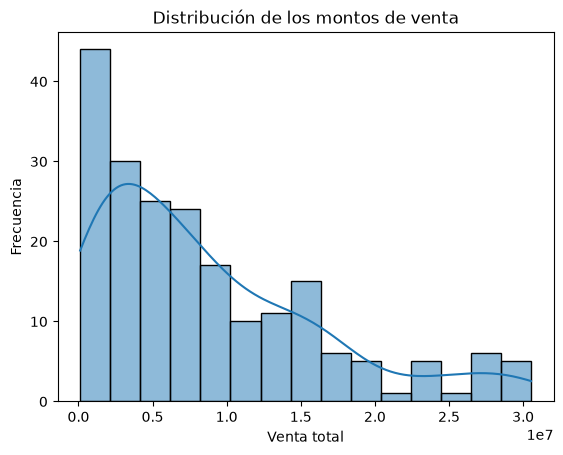

In [11]:
# 1. Crear el histograma usando la columna venta_total
sns.histplot(
    data=df,
    x="venta_total",
    kde=True,
    bins=15
)

# 2. Agregar el título de la gráfica
plt.title("Distribución de los montos de venta")

# 3. Agregar el nombre del eje X
plt.xlabel("Venta total")

# 4. Agregar el nombre del eje Y
plt.ylabel("Frecuencia")

# 5. Mostrar la gráfica
plt.show()

Ejercicio 6: Mapa de Calor de Correlaciones Numéricas (sns.heatmap)

* Contexto:

Queremos analizar el grado de correlación lineal entre las variables numéricas del DataFrame (precio, cantidad y venta_total).

* Instrucción:

Selecciona únicamente las columnas numéricas del DataFrame, calcula la matriz de correlación mediante .select_dtypes(include="number").corr(), y grafícala usando sns.heatmap() con anotaciones numéricas activadas (annot=True, fmt=".2f", esquema de color "coolwarm").

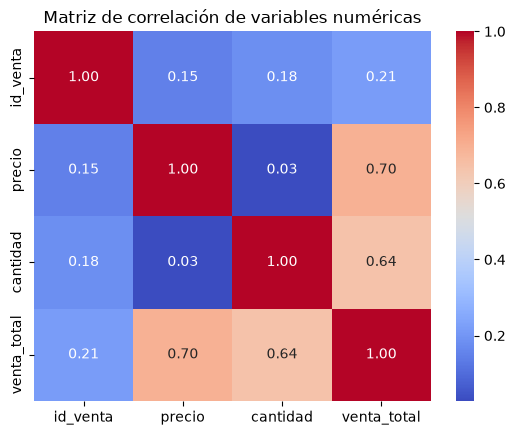

In [12]:
# 1. Crear la matriz de correlación con las columnas numéricas
correlacion = df.select_dtypes(include="number").corr()

# 2. Crear el mapa de calor
sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

# 3. Agregar título
plt.title("Matriz de correlación de variables numéricas")

# 4. Mostrar la gráfica
plt.show()